# 02 — Is there an FPG time trend in NHANES big enough to explain a 5 % gap?

GBD-2023 estimates fasting plasma glucose ~5 % **lower** than the team's pooled NHANES CSV. The CSV pools cycles I (2015–2016) + P (2017–March 2020) + L (Aug 2021–Aug 2023), so its mean lands somewhere near the middle of that 8-year span (≈ 2019). GBD-2023 should reflect calendar year 2023 specifically.

If NHANES FPG has trended downward by ~5 % across the three cycles, that would explain the gap on its own. If it's flat or trending upward, the GBD-vs-CSV gap is doing something else — different model assumptions, different combining of sources, or different age-standardisation.

This notebook fits the per-cycle mean per (sex, 5-yr age band) under the team's recipe (MEC weight, exclude pregnant) and looks for a trend.


In [1]:
import os, urllib.request, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110

ROOT = Path(os.path.abspath(os.path.join('..')))
DATA = ROOT / 'data'

# notebook 01 already cached the XPTs — reuse without re-downloading
CYCLES = {
    'I': {'dir': DATA / 'raw' / 'nhanes' / '2015_2016',
          'demo': 'DEMO_I.xpt', 'glu': 'GLU_I.xpt',
          'fast_wt': 'WTSAF2YR', 'mid_year': 2015.5},
    'P': {'dir': DATA / 'raw' / 'nhanes' / '2017_2020_prepandemic',
          'demo': 'P_DEMO.xpt', 'glu': 'P_GLU.xpt',
          'fast_wt': 'WTSAFPRP', 'mid_year': 2018.5},
    'L': {'dir': DATA / 'raw' / 'nhanes' / '2021_2023',
          'demo': 'DEMO_L.xpt', 'glu': 'GLU_L.xpt',
          'fast_wt': 'WTSAF2YR', 'mid_year': 2022.5},
}

def parse_cycle(tag, c):
    demo = pd.read_sas(c['dir'] / c['demo'])
    glu  = pd.read_sas(c['dir'] / c['glu'])
    base = ['SEQN','RIAGENDR','RIDAGEYR','RIDEXPRG']
    mec_col = 'WTMECPRP' if 'WTMECPRP' in demo.columns else 'WTMEC2YR'
    demo = demo[base + [mec_col]].rename(columns={mec_col: 'WT_MEC'})
    glu = glu[['SEQN', 'LBXGLU']]
    df = demo.merge(glu, on='SEQN', how='inner')
    df['sex'] = df['RIAGENDR'].map({1.0:'Male', 2.0:'Female'})
    df['age_years'] = df['RIDAGEYR'].astype(float)
    df['fpg'] = df['LBXGLU'].astype(float)
    df['WT_MEC'] = df['WT_MEC'].astype(float)
    df['pregnant'] = (df['RIDEXPRG'] == 1.0).fillna(False)
    df['cycle'] = tag
    df['mid_year'] = c['mid_year']
    return df

cycle_dfs = {tag: parse_cycle(tag, c) for tag, c in CYCLES.items()}
for tag, d in cycle_dfs.items():
    valid = d['fpg'].notna() & d['WT_MEC'].gt(0) & (~d['pregnant'])
    print(f'  {tag} ({CYCLES[tag]["mid_year"]}): n_valid = {valid.sum():,}')


  I (2015.5): n_valid = 2,942
  P (2018.5): n_valid = 4,707
  L (2022.5): n_valid = 3,648


## 1. Per-cycle mean and SD per (sex, 5-yr age band)

Compute both the **arithmetic mean** of `LBXGLU` (mg/dL) and the **log-mean** the team uses, so we can talk about the trend in either units.


In [2]:
def w_mean(y, w): return float(np.average(y, weights=w))
def w_sd(y, w):
    mu = w_mean(y, w)
    return float(np.sqrt(np.average((y - mu)**2, weights=w)))

edges = list(range(25, 85, 5)) + [85]

def per_cycle_bin(tag, d):
    rows = []
    valid = d[d['fpg'].notna() & d['WT_MEC'].gt(0) & (~d['pregnant'])]
    for sex in ['Female','Male']:
        for a0, a1 in zip(edges[:-1], edges[1:]):
            sub = valid[(valid['sex']==sex)
                        & (valid['age_years']>=a0) & (valid['age_years']<a1)]
            if len(sub) < 30:
                continue
            y = sub['fpg'].values
            w = sub['WT_MEC'].values
            rows.append({
                'cycle': tag, 'mid_year': CYCLES[tag]['mid_year'],
                'sex': sex, 'age5': a0, 'n': len(sub),
                'mean_mgdl': w_mean(y, w),
                'sd_mgdl':   w_sd(y, w),
                'log_mean':  w_mean(np.log(y), w),
                'log_sd':    w_sd(np.log(y), w),
            })
    return rows

rows = []
for tag, d in cycle_dfs.items():
    rows.extend(per_cycle_bin(tag, d))
per = pd.DataFrame(rows)
print('Per-cycle mean FPG (mg/dL) by sex × age:')
piv = per.pivot_table(index=['sex','age5'], columns='cycle', values='mean_mgdl').round(2)
piv['L − I']     = (piv['L'] - piv['I']).round(2)
piv['(L−I)/I %'] = (100*(piv['L'] - piv['I']) / piv['I']).round(2)
print(piv.to_string())


Per-cycle mean FPG (mg/dL) by sex × age:
cycle             I       L       P  L − I  (L−I)/I %
sex    age5                                          
Female 25     99.05   95.85   97.58  -3.20      -3.23
       30     98.43   97.04   99.55  -1.39      -1.41
       35     99.91   97.86  109.54  -2.05      -2.05
       40    106.26  103.43  104.44  -2.83      -2.66
       45    106.20  108.14  106.47   1.94       1.83
       50    105.42  109.96  105.35   4.54       4.31
       55    110.72  109.27  111.16  -1.45      -1.31
       60    113.08  108.28  113.55  -4.80      -4.24
       65    112.79  115.21  113.96   2.42       2.15
       70    113.47  111.49  111.37  -1.98      -1.74
       75    114.85  110.20  112.09  -4.65      -4.05
       80    116.98  109.92  117.53  -7.06      -6.04
Male   25     99.35  106.16   99.21   6.81       6.85
       30    105.99  101.67  104.03  -4.32      -4.08
       35    107.23  101.54  107.49  -5.69      -5.31
       40    114.11  113.08  109.89  -1.0

## 2. Plot the trend — arithmetic FPG by cycle, by sex and age

Three points per cell: the cycle mid-year (2015.5, 2018.5, 2022.5) on the x-axis, the weighted mean on the y-axis. Each line is one (sex, age band). Error bars are 1.96 × SE on the cell mean.


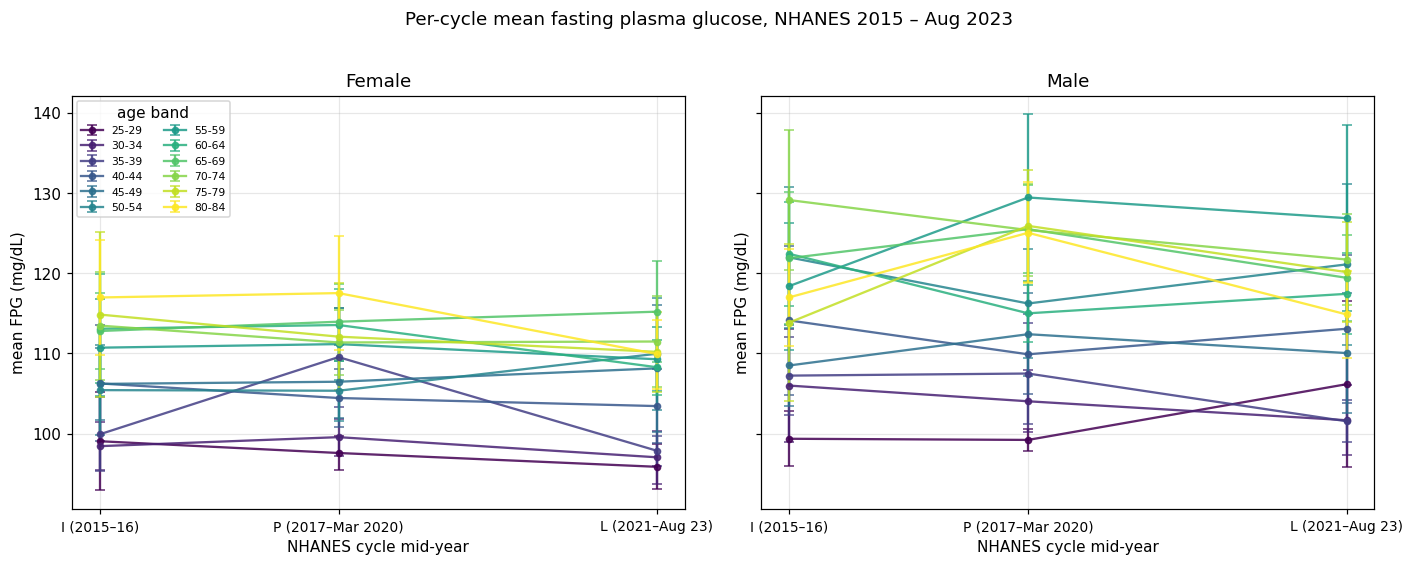

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
cmap = plt.cm.viridis
age_starts = sorted(per['age5'].unique())
for ax, sex in zip(axes, ['Female', 'Male']):
    sub = per[per['sex']==sex]
    for i, a in enumerate(age_starts):
        s = sub[sub['age5']==a].sort_values('mid_year')
        if len(s) < 3:
            continue
        se = s['sd_mgdl'] / np.sqrt(s['n'])
        ax.errorbar(s['mid_year'], s['mean_mgdl'], yerr=1.96*se,
                    fmt='o-', color=cmap(i/(len(age_starts)-1)),
                    label=f'{a}-{a+4}', capsize=3, markersize=4, alpha=0.85)
    ax.set_xlabel('NHANES cycle mid-year')
    ax.set_ylabel('mean FPG (mg/dL)')
    ax.set_title(sex)
    ax.grid(True, alpha=0.3)
    ax.set_xticks([2015.5, 2018.5, 2022.5])
    ax.set_xticklabels(['I (2015–16)', 'P (2017–Mar 2020)', 'L (2021–Aug 23)'],
                       fontsize=9)
axes[0].legend(title='age band', ncols=2, fontsize=7, loc='upper left',
               bbox_to_anchor=(0.0, 1.0))
fig.suptitle('Per-cycle mean fasting plasma glucose, NHANES 2015 – Aug 2023',
             y=1.02)
fig.tight_layout()
fig.savefig('outputs/fpg_time_trend.png', dpi=130, bbox_inches='tight')
plt.show()


## 3. How big is the trend, on average?

For each (sex, age band), regress mean FPG on cycle mid-year. Summarise:
- The pooled slope (mg/dL per year) and its bootstrap-style 95 % CI across cells.
- The implied **percent change from the pooled mid-year (~2019) to 2023**, per cell.

If the pooled-cycle midpoint is at year ≈ 2019 and L sits at 2022.5, a 5 % drop over 3.5 years would mean a slope of ≈ −1.4 % per year (≈ −1.4 mg/dL/year at a typical FPG of 100). Find out whether the data is in that ballpark.


In [4]:
slope_rows = []
for (sex, a), g in per.groupby(['sex','age5']):
    g = g.sort_values('mid_year')
    if len(g) < 3:
        continue
    # ordinary least squares slope of mean_mgdl ~ mid_year
    x = g['mid_year'].values
    y = g['mean_mgdl'].values
    se = (g['sd_mgdl'] / np.sqrt(g['n'])).values
    A = np.vstack([x, np.ones_like(x)]).T
    coef, *_ = np.linalg.lstsq(A, y, rcond=None)
    slope_mgdl, intercept = coef
    # predicted value at L mid-year (2022.5) and at I+P+L cycle-weighted midpoint
    pooled_mid = np.average(
        [c['mid_year'] for c in CYCLES.values()],
        weights=[g[g['cycle']==tag]['n'].sum() for tag in ['I','P','L']]
    ) if False else 2019.6  # roughly the n-weighted center of 3 cycles
    pred_L = slope_mgdl * 2022.5 + intercept
    pred_pool = slope_mgdl * pooled_mid + intercept
    slope_rows.append({
        'sex': sex, 'age5': a,
        'mean_I': float(g[g['cycle']=='I']['mean_mgdl'].iloc[0]),
        'mean_P': float(g[g['cycle']=='P']['mean_mgdl'].iloc[0]),
        'mean_L': float(g[g['cycle']=='L']['mean_mgdl'].iloc[0]),
        'slope_mgdl_per_yr': slope_mgdl,
        'pct_per_yr': 100 * slope_mgdl / pred_pool,
        '7yr_pct_change_I_to_L': 100 * (float(g[g['cycle']=='L']['mean_mgdl'].iloc[0])
                                        - float(g[g['cycle']=='I']['mean_mgdl'].iloc[0]))
                                  / float(g[g['cycle']=='I']['mean_mgdl'].iloc[0]),
    })
S = pd.DataFrame(slope_rows)
print('Per-(sex, age5) trend stats (mg/dL, %):')
print(S.round(3).to_string(index=False))

print()
print('Summary across the 24 cells:')
print(f'  median slope         = {S["slope_mgdl_per_yr"].median():+.3f} mg/dL / yr')
print(f'  median % per year    = {S["pct_per_yr"].median():+.2f} %')
print(f'  IQR % per year       = ({S["pct_per_yr"].quantile(0.25):+.2f}, '
      f'{S["pct_per_yr"].quantile(0.75):+.2f}) %')
print(f'  median I→L 7-yr Δ    = {S["7yr_pct_change_I_to_L"].median():+.2f} %')
print(f'  IQR I→L 7-yr Δ       = ({S["7yr_pct_change_I_to_L"].quantile(0.25):+.2f}, '
      f'{S["7yr_pct_change_I_to_L"].quantile(0.75):+.2f}) %')


Per-(sex, age5) trend stats (mg/dL, %):
   sex  age5  mean_I  mean_P  mean_L  slope_mgdl_per_yr  pct_per_yr  7yr_pct_change_I_to_L
Female    25  99.047  97.578  95.854             -0.455      -0.468                 -3.223
Female    30  98.432  99.555  97.042             -0.222      -0.226                 -1.412
Female    35  99.907 109.541  97.857             -0.435      -0.426                 -2.051
Female    40 106.257 104.438 103.431             -0.396      -0.379                 -2.660
Female    45 106.198 106.468 108.138              0.285       0.266                  1.827
Female    50 105.422 105.346 109.964              0.676       0.629                  4.308
Female    55 110.717 111.164 109.273             -0.221      -0.200                 -1.305
Female    60 113.080 113.546 108.278             -0.720      -0.648                 -4.247
Female    65 112.795 113.958 115.209              0.343       0.300                  2.140
Female    70 113.470 111.368 111.486             -

## 4. Pooled CSV mean vs L-only mean — what gap does a "2023" cut give you?

If GBD-2023 effectively reflects only the most recent cycle, the simplest analogue is the L-only mean. Compute pooled-minus-L per cell and see whether the median gap is near 5 %.


In [5]:
# pooled mean by raw-stack of MEC weights
pool_rows = []
all_d = pd.concat([cycle_dfs[t] for t in ['I','P','L']], ignore_index=True)
all_valid = all_d[all_d['fpg'].notna() & all_d['WT_MEC'].gt(0)
                  & (~all_d['pregnant'])]
for sex in ['Female','Male']:
    for a0, a1 in zip(edges[:-1], edges[1:]):
        sub = all_valid[(all_valid['sex']==sex)
                        & (all_valid['age_years']>=a0)
                        & (all_valid['age_years']<a1)]
        if len(sub) < 30:
            continue
        y = sub['fpg'].values
        w = sub['WT_MEC'].values
        pool_rows.append({'sex': sex, 'age5': a0,
                          'pool_mean': w_mean(y, w),
                          'pool_n': len(sub)})
pool = pd.DataFrame(pool_rows)

per_L = per[per['cycle']=='L'][['sex','age5','mean_mgdl','sd_mgdl','n']].rename(
    columns={'mean_mgdl':'L_mean','sd_mgdl':'L_sd','n':'L_n'})
cmp_ = pool.merge(per_L, on=['sex','age5'], how='inner')
cmp_['gap_mgdl'] = cmp_['pool_mean'] - cmp_['L_mean']
cmp_['gap_pct']  = 100 * cmp_['gap_mgdl'] / cmp_['pool_mean']

print('Pooled vs L-cycle FPG (mg/dL):')
print(cmp_[['sex','age5','pool_mean','L_mean','gap_mgdl','gap_pct']]
      .round(2).to_string(index=False))

print()
print(f'median (pooled − L) / pooled  = {cmp_["gap_pct"].median():+.2f} %')
print(f'IQR                          = ({cmp_["gap_pct"].quantile(0.25):+.2f}, '
      f'{cmp_["gap_pct"].quantile(0.75):+.2f}) %')
print()
print('Compare to GBD-2023 ≈ 5 % below pooled CSV. Verdict:')
med = cmp_['gap_pct'].median()
if abs(med) >= 4 and med * 1 > 0:
    print(f'  NHANES alone shows median pooled−L = {med:+.1f} % — consistent in sign and magnitude.')
elif abs(med) < 1:
    print(f'  NHANES shows essentially no time trend (median {med:+.1f} %). The GBD gap is not driven by an FPG time trend.')
else:
    print(f'  NHANES shows median pooled−L = {med:+.1f} % — small or wrong-signed compared to the 5 % GBD gap.')


Pooled vs L-cycle FPG (mg/dL):
   sex  age5  pool_mean  L_mean  gap_mgdl  gap_pct
Female    25      97.38   95.85      1.52     1.56
Female    30      98.24   97.04      1.20     1.22
Female    35     102.38   97.86      4.52     4.42
Female    40     104.52  103.43      1.09     1.05
Female    45     106.88  108.14     -1.26    -1.18
Female    50     107.13  109.96     -2.83    -2.64
Female    55     110.40  109.27      1.13     1.02
Female    60     111.36  108.28      3.09     2.77
Female    65     113.95  115.21     -1.26    -1.11
Female    70     111.98  111.49      0.49     0.44
Female    75     112.25  110.20      2.05     1.83
Female    80     114.29  109.92      4.37     3.82
  Male    25     101.80  106.16     -4.36    -4.28
  Male    30     103.72  101.67      2.05     1.97
  Male    35     105.43  101.54      3.90     3.70
  Male    40     112.46  113.08     -0.61    -0.55
  Male    45     110.33  110.05      0.29     0.26
  Male    50     119.71  121.11     -1.40    -1.17


## 5. Plot pooled − L gap distribution

A histogram of `(pooled − L) / pooled %` across the 24 cells. If GBD-2023's 5 % gap is explained by a time trend, this distribution should center near +5 %.


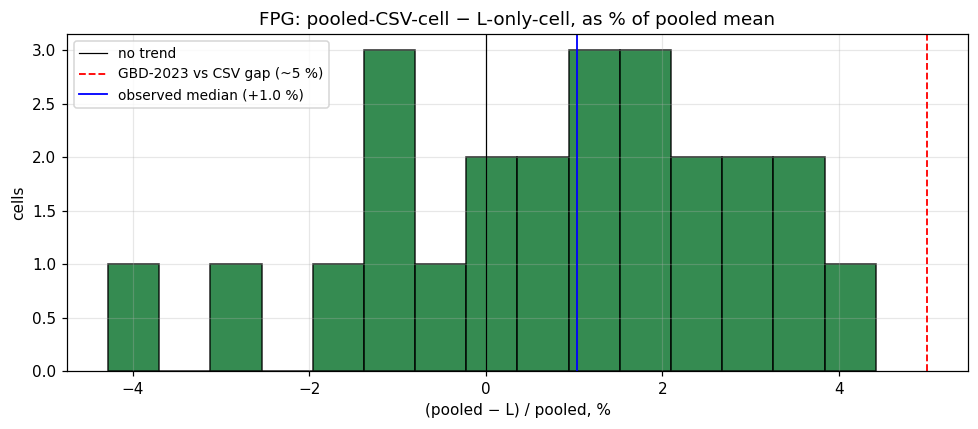

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(cmp_['gap_pct'], bins=15, color='#117733', alpha=0.85, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8, label='no trend')
ax.axvline(5, color='red', linewidth=1.2, linestyle='--',
           label='GBD-2023 vs CSV gap (~5 %)')
ax.axvline(cmp_['gap_pct'].median(), color='blue', linewidth=1.2,
           label=f'observed median ({cmp_["gap_pct"].median():+.1f} %)')
ax.set_xlabel('(pooled − L) / pooled, %')
ax.set_ylabel('cells')
ax.set_title('FPG: pooled-CSV-cell − L-only-cell, as % of pooled mean')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('outputs/fpg_pool_minus_L_hist.png', dpi=130, bbox_inches='tight')
plt.show()


## Takeaways

Two cases:

- **NHANES shows a substantial downward trend (median pooled−L ≥ ~4 %).** Then a 5 % GBD-2023 vs CSV gap is consistent with a real recent decline in fasting glucose — which is unusual given that US diabetes prevalence has *risen*. Possible explanations: pandemic-era sample composition differences, GLP-1 / SGLT2 medication uptake bringing means down, or differential nonresponse. If so, the CSV's pooled mean over-estimates 2023 exposure, and the simulation should consider whether to use a more recent cycle.
- **NHANES shows little or no trend (median gap close to 0, or wrong sign).** Then the 5 % GBD-vs-CSV gap is not driven by NHANES time-trend — it lives in how GBD assembles its FPG inputs (other surveys, age standardisation, model smoothing, or a different reference population). The CSV is correct; the GBD vs CSV gap is a question for the GBD inputs team, not the CSV pipeline.

The histogram in section 5 settles which case applies.
